In [1]:
import sys, tensorflow as tf #nformation about the Python environment, ML library used for neural networks and TensorFlow Lite conversion.
print(sys.version)
print(tf.__version__)

3.9.0 (tags/v3.9.0:9cf6752, Oct  5 2020, 15:34:40) [MSC v.1927 64 bit (AMD64)]
2.10.0


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.callbacks import EarlyStopping

In [3]:

df_header = pd.read_csv("edge_impulse_dataset.csv", nrows=0)
print(df_header.columns) #columns exist in the dataset.

Index(['R ', 'G ', 'B ', 'I ', 'temperature', 'pressure', 'humidity',
       'gas res', 'label'],
      dtype='object')


In [4]:

df = pd.read_csv(
    "edge_impulse_dataset.csv",
    engine="python",
    on_bad_lines="skip"
)

df.columns = df.columns.str.strip()

df = df[['I']]   # keep light sensor

print(df.head())
print(df.shape)

        I
0  1242.0
1  1242.0
2  1242.0
3  1242.0
4  1241.0
(923471, 1)


In [5]:
df['I'] = pd.to_numeric(df['I'], errors='coerce')
df = df.dropna()
print(df.shape)

(923471, 1)


In [6]:
print(df['I'].min(), df['I'].max())

0.0 7664.0


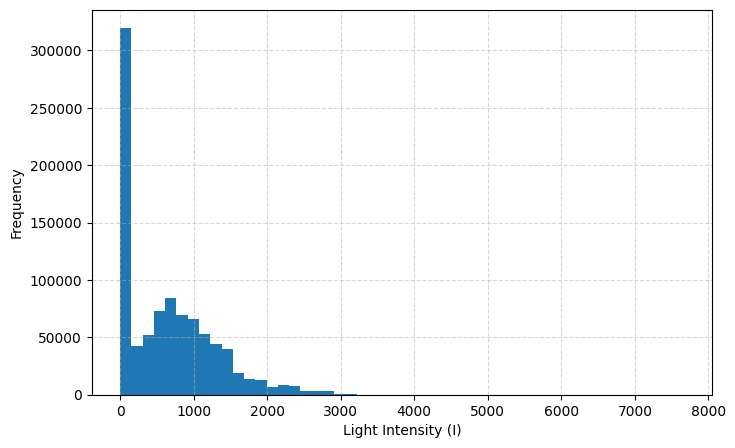

In [7]:
plt.figure(figsize=(8,5))
plt.hist(df['I'], bins=50)
#Add these lines
plt.xlabel("Light Intensity (I)")   # X-axis
plt.ylabel("Frequency")             # Y-axis
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [8]:
print(df.isna().sum())

I    0
dtype: int64


In [9]:
ORIGINAL_FREQ = 1   # dataset collected every 1 second
TARGET_FREQ = 10    # want one sample every 10 seconds
STEP = TARGET_FREQ // ORIGINAL_FREQ   # = 10
df_resampled = df.iloc[::STEP].reset_index(drop=True)
print("Original dataset size:", df.shape)
print("Resampled dataset size:", df_resampled.shape)
# Replace df with resampled version for the rest of the pipeline
df = df_resampled

Original dataset size: (923471, 1)
Resampled dataset size: (92348, 1)


In [10]:
df['Time (s)'] = df.index * 10 #time axis 

In [11]:

print(df.head())
print(df.shape)

        I  Time (s)
0  1242.0         0
1  1241.0        10
2  1240.0        20
3  1238.0        30
4  1237.0        40
(92348, 2)


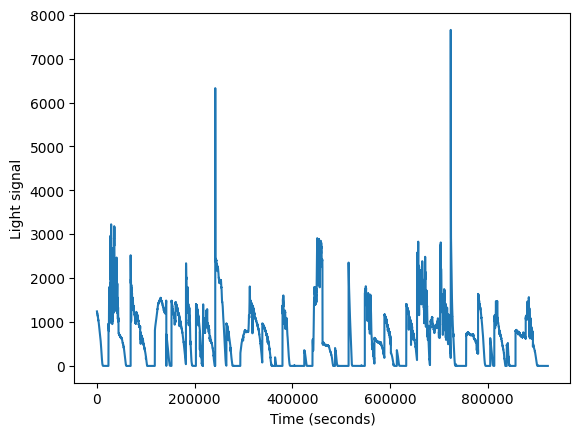

In [12]:
plt.plot(df['Time (s)'], df['I'])
plt.xlabel("Time (seconds)")
plt.ylabel("Light signal")
plt.show()

In [13]:
# EWMA smoothing for multiple alpha values
ALPHAS = [0.05, 0.1, 0.2, 0.3]

for alpha in ALPHAS:
    df[f'I_ewma_{alpha}'] = df['I'].ewm(alpha=alpha, adjust=False).mean()

# Quick check
df[['I', 'I_ewma_0.05', 'I_ewma_0.1', 'I_ewma_0.2']].head()

,I,I_ewma_0.05,I_ewma_0.1,I_ewma_0.2
0,1242.0,1242.000000,1242.0000,1242.0000
1,1241.0,1241.950000,1241.9000,1241.8000
2,1240.0,1241.852500,1241.7100,1241.4400
3,1238.0,1241.659875,1241.3390,1240.7520
4,1237.0,1241.426881,1240.9051,1240.0016


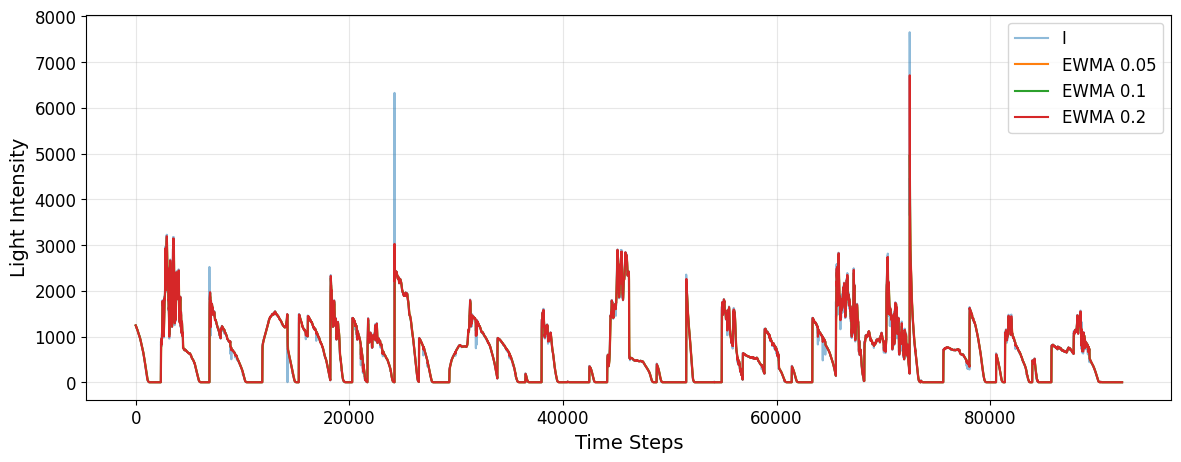

In [14]:
plt.figure(figsize=(14, 5))

plt.plot(df['I'].values, label='I', alpha=0.5)
plt.plot(df['I_ewma_0.05'].values, label='EWMA 0.05')
plt.plot(df['I_ewma_0.1'].values, label='EWMA 0.1')
plt.plot(df['I_ewma_0.2'].values, label='EWMA 0.2')

plt.xlabel("Time Steps", fontsize=14)
plt.ylabel("Light Intensity", fontsize=14)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Increase legend size
plt.legend(fontsize=12)

plt.grid(alpha=0.3)
plt.show()

In [15]:
alpha_chosen = 0.1
signal = df[f'I_ewma_{alpha_chosen}'].values

In [16]:
def create_sliding_windows(signal, window_size):
    X, y = [], []
    for i in range(window_size, len(signal)):
        X.append(signal[i - window_size:i])
        y.append(signal[i])
    return np.array(X), np.array(y)

In [17]:
from lightgbm import LGBMRegressor
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error

In [18]:
WINDOW_SIZE = 25
X, y = create_sliding_windows(signal, WINDOW_SIZE)

# Time-based split (70 / 15 / 15)
N = len(X)
train_end = int(0.7 * N)
val_end   = int(0.85 * N)

X_train, y_train = X[:train_end], y[:train_end]
X_val,   y_val   = X[train_end:val_end], y[train_end:val_end]
X_test,  y_test  = X[val_end:], y[val_end:]

In [19]:
best_params = {
    "learning_rate": 0.1,
    "num_leaves": 31,
    "min_child_samples": 40,
    "max_depth": -1,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "random_state": 42
}

model = LGBMRegressor(
    n_estimators=1000,   # upper bound
    **best_params
)

model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    eval_metric="l1",
    callbacks=[
        lgb.early_stopping(150),
        lgb.log_evaluation(200)
    ]
)

# Final test prediction
y_test_pred = model.predict(X_test, num_iteration=model.best_iteration_)

test_mae = mean_absolute_error(y_test, y_test_pred)

print(f"FINAL TEST MAE = {test_mae:.6f}")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005520 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6375
[LightGBM] [Info] Number of data points in the train set: 64626, number of used features: 25
[LightGBM] [Info] Start training from score 636.173006
Training until validation scores don't improve for 150 rounds
[200]	valid_0's l1: 9.68428	valid_0's l2: 6566.84
[400]	valid_0's l1: 9.64677	valid_0's l2: 6554.55
[600]	valid_0's l1: 9.61715	valid_0's l2: 6553.98
Early stopping, best iteration is:
[595]	valid_0's l1: 9.61541	valid_0's l2: 6552.41
FINAL TEST MAE = 1.930627


c:\Users\maria\tf39_env\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [20]:
model.booster_.save_model("lgbm_model.txt")
#accesses the internal LightGBM model (trees and save it to a file

In [21]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

test_mae  = mean_absolute_error(y_test, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_r2   = r2_score(y_test, y_test_pred)

print(f"TEST MAE  = {test_mae:.6f}")
print(f"TEST RMSE = {test_rmse:.6f}")
print(f"TEST R²   = {test_r2:.6f}")
print(f"Best iteration used = {model.best_iteration_}")

TEST MAE  = 1.930627
TEST RMSE = 3.695620
TEST R²   = 0.999926
Best iteration used = 595


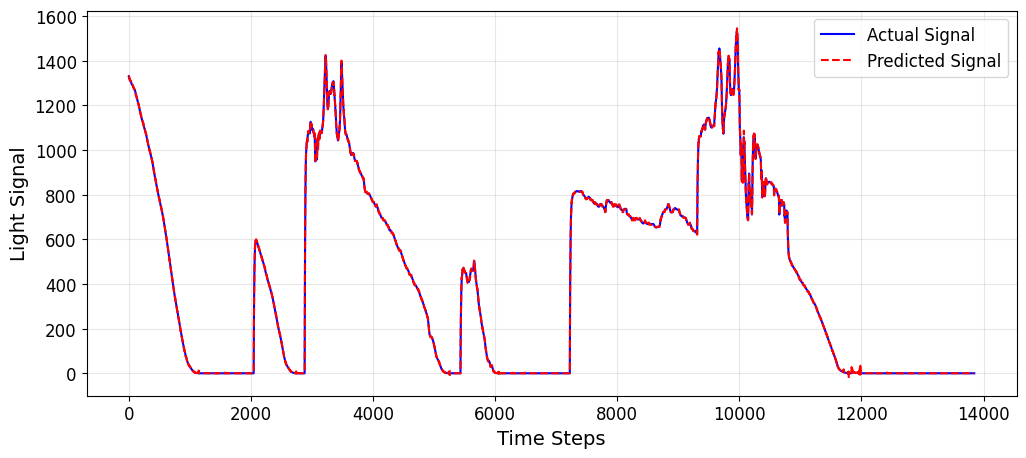

In [22]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(12, 5))

plt.plot(y_test, label="Actual Signal", color="blue", linewidth=1.5)
plt.plot(y_test_pred, label="Predicted Signal", color="red", linestyle="--", linewidth=1.5)

# Bigger axis labels
plt.xlabel("Time Steps", fontsize=14)
plt.ylabel("Light Signal", fontsize=14)

# Bigger ticks
plt.xticks(fontsize=12) #Ticks are the numbers/marks on the axes.
plt.yticks(fontsize=12)

# Bigger legend  #The legend tells you what each line/color represents in a graph
plt.legend(fontsize=12)
plt.grid(alpha=0.3)
plt.show()

In [23]:
import numpy as np

errors = np.abs(y_test - y_test_pred)

def accuracy_at_threshold(errors, threshold):
    return np.mean(errors <= threshold)

acc_2  = accuracy_at_threshold(errors, 2)
acc_5  = accuracy_at_threshold(errors, 5)
acc_10 = accuracy_at_threshold(errors, 10)

print(f"Accuracy (2 units)  = {acc_2*100:.2f}%")
print(f"Accuracy (5 units)  = {acc_5*100:.2f}%")
print(f"Accuracy (10 units) = {acc_10*100:.2f}%")

Accuracy (2 units)  = 64.06%
Accuracy (5 units)  = 92.40%
Accuracy (10 units) = 98.21%


In [24]:
# Save LightGBM model for Edge Impulse
model.booster_.save_model("lightgbm_model.txt")

print("Saved lightgbm_model.txt")

Saved lightgbm_model.txt


# For Tensorflow lite
LightGBM cannot be converted directly to TensorFlow Lite.

LightGBM is NOT a neural network

It is a tree ensemble (decision trees + boosting)

TensorFlow Lite only supports neural-network graphs

Create a Keras “student” model (regression)

So, You distill the LightGBM into a small Keras neural network, then convert that to TFLite.

In [25]:
# Teacher predictions (LightGBM)
y_teacher = model.predict(X_train)


c:\Users\maria\tf39_env\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [26]:
student = Sequential([
    Input(shape=(25,)),  # window size
    Dense(16, activation="relu"),
    Dense(8, activation="relu"),
    Dense(1)                            # regression output
])

student.compile(
    optimizer="adam",
    loss="mae"
)

In [27]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    min_delta=1e-4
)
#use for best epochs

Patience = how many epochs to wait after validation stops improving

min_delta=1e-4?,
This avoids stopping for meaningless improvements.

Train student with early stopping

In [28]:
SCALE = 3500.0

X_train_scaled = X_train / SCALE
X_val_scaled   = X_val   / SCALE
X_test_scaled  = X_test  / SCALE

y_teacher_scaled = y_teacher / SCALE

In [29]:
history = student.fit(
    X_train_scaled,
    y_teacher_scaled,
    epochs=100,
    batch_size=1024,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
57/57 [==============================] - 1s 8ms/step - loss: 0.1170 - val_loss: 0.0080
Epoch 2/100
57/57 [==============================] - 0s 4ms/step - loss: 0.0053 - val_loss: 0.0018
Epoch 3/100
57/57 [==============================] - 0s 3ms/step - loss: 0.0034 - val_loss: 0.0017
Epoch 4/100
57/57 [==============================] - 0s 4ms/step - loss: 0.0027 - val_loss: 0.0019
Epoch 5/100
57/57 [==============================] - 0s 4ms/step - loss: 0.0023 - val_loss: 9.8145e-04
Epoch 6/100
57/57 [==============================] - 0s 3ms/step - loss: 0.0019 - val_loss: 0.0010
Epoch 7/100
57/57 [==============================] - 0s 4ms/step - loss: 0.0019 - val_loss: 0.0016
Epoch 8/100
57/57 [==============================] - 0s 3ms/step - loss: 0.0022 - val_loss: 0.0014
Epoch 9/100
57/57 [==============================] - 0s 4ms/step - loss: 0.0025 - val_loss: 0.0019
Epoch 10/100
57/57 [==============================] - 0s 3ms/step - loss: 0.0022 - val_loss: 8.8209e-04


See how many epochs actually used

In [30]:
best_epoch = np.argmin(history.history["val_loss"]) + 1
print("Best epoch selected by early stopping:", best_epoch)

Best epoch selected by early stopping: 10


In [31]:
y_student_test_scaled = student.predict(X_test_scaled).flatten()
y_student_test = y_student_test_scaled * SCALE



433/433 [==============================] - 1s 1ms/step


In [32]:
student.save("student_saved_model")
print("Student model exported as SavedModel")

INFO:tensorflow:Assets written to: student_saved_model\assets
Student model exported as SavedModel


In [33]:
converter = tf.lite.TFLiteConverter.from_saved_model("student_saved_model")

converter.optimizations = [tf.lite.Optimize.DEFAULT]

# STRICT micro compatibility
converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS
]

converter.experimental_enable_resource_variables = False

tflite_model = converter.convert()

with open("student_tflm_compatible.tflite", "wb") as f:
    f.write(tflite_model)

print(" TFLite Micro compatible model created")

 TFLite Micro compatible model created


Run the TFLite model on your laptop CPU and compare predictions to the TensorFlow student model.

In [34]:
interpreter = tf.lite.Interpreter(
    model_path="student_tflm_compatible.tflite"
)
interpreter.allocate_tensors()

Think of this like starting a machine:

Interpreter(...)

Loads the .tflite file into memory (RAM)

allocate_tensors()

Creates space for:

input tensor (25 values)

output tensor (1 value)

This is what was meant by
“assigning tensors and hardware resources”

In [35]:
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

The model tells you:

Where to put input data

Where to read output data

In [36]:
input_details, output_details

([{'name': 'serving_default_input_1:0',
   'index': 0,
   'shape': array([ 1, 25]),
   'shape_signature': array([-1, 25]),
   'dtype': numpy.float32,
   'quantization': (0.0, 0),
   'quantization_parameters': {'scales': array([], dtype=float32),
    'zero_points': array([], dtype=int32),
    'quantized_dimension': 0},
   'sparsity_parameters': {}}],
 [{'name': 'StatefulPartitionedCall:0',
   'index': 9,
   'shape': array([1, 1]),
   'shape_signature': array([-1,  1]),
   'dtype': numpy.float32,
   'quantization': (0.0, 0),
   'quantization_parameters': {'scales': array([], dtype=float32),
    'zero_points': array([], dtype=int32),
    'quantized_dimension': 0},
   'sparsity_parameters': {}}])

In [37]:
# Run TFLite on full test set
tflite_preds_scaled = []

for i in range(len(X_test_scaled)):

    sample = X_test_scaled[i].astype(np.float32).reshape(1, 25)

    interpreter.set_tensor(input_details[0]['index'], sample)
    interpreter.invoke()

    pred = interpreter.get_tensor(output_details[0]['index'])[0][0]
    tflite_preds_scaled.append(pred)

tflite_preds_scaled = np.array(tflite_preds_scaled)

# Back to original units
tflite_preds = tflite_preds_scaled * SCALE

In [38]:
tf_student_preds=student.predict(X_test_scaled)

433/433 [==============================] - 1s 1ms/step


In [39]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def evaluate(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    print("MAE :", mae)
    print("RMSE:", rmse)
    print("R2  :", r2)

In [40]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def evaluate(name, y_true, y_pred):

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    print(f"\n{name}")
    print("MAE :", mae)
    print("RMSE:", rmse)
    print("R2  :", r2)


evaluate("Teacher vs Real", y_test, model.predict(X_test))
evaluate("Student vs Real", y_test, student.predict(X_test_scaled) * SCALE)
evaluate("TFLite vs Real", y_test, tflite_preds)

c:\Users\maria\tf39_env\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(



Teacher vs Real
MAE : 1.9306273455084686
RMSE: 3.6956200584609067
R2  : 0.9999263837753956
433/433 [==============================] - 1s 1ms/step

Student vs Real
MAE : 4.1390722674439715
RMSE: 12.108391294560594
R2  : 0.9992097367175645

TFLite vs Real
MAE : 4.139074074053481
RMSE: 12.108392896265284
R2  : 0.9992097365084917


In [41]:
tf_student_preds = student.predict(X_test_scaled).flatten() * SCALE
# tflite_preds already multiplied by SCALE earlier

433/433 [==============================] - 1s 1ms/step


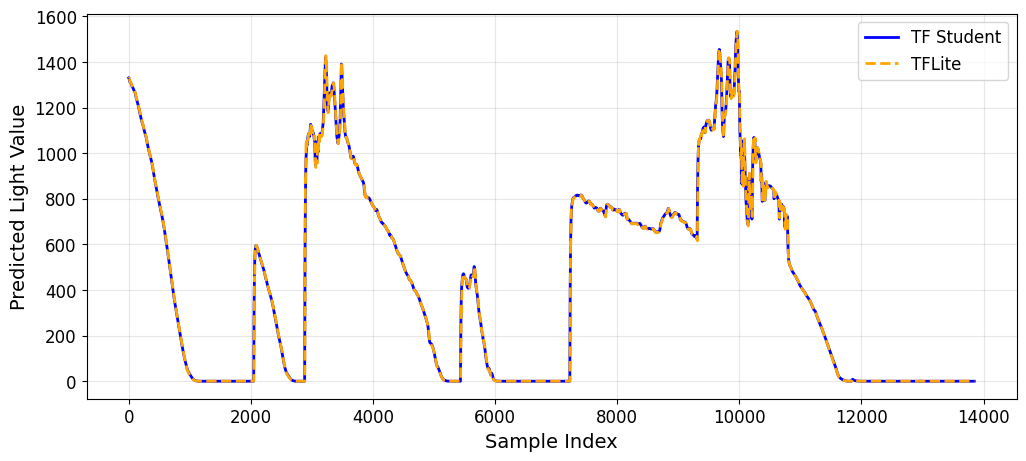

In [42]:
plt.figure(figsize=(12, 5))

plt.plot(y_test, label="TF Student", color="blue", linewidth=2)
plt.plot(tflite_preds, label="TFLite", color="orange", linestyle="--", linewidth=2)

# Bigger axis labels
plt.xlabel("Sample Index", fontsize=14)
plt.ylabel("Predicted Light Value", fontsize=14)

# Bigger ticks
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Bigger legend
plt.legend(fontsize=12)

# Optional title (good for thesis)
# plt.title("TF Student vs TFLite Predictions", fontsize=16)

plt.grid(alpha=0.3)

plt.show()

In [43]:
import numpy as np
import tensorflow as tf

# Load TFLite model
interpreter = tf.lite.Interpreter(model_path="student_tflm_compatible.tflite")
interpreter.allocate_tensors()

details = interpreter.get_tensor_details()

arena_size = 0

for tensor in details:
    shape = tensor["shape"]
    dtype = tensor["dtype"]

    num_elements = np.prod(shape)
    bytes_per_element = np.dtype(dtype).itemsize

    arena_size += num_elements * bytes_per_element

print("Estimated arena size (bytes):", arena_size)
print("Estimated arena size (KB):", arena_size / 1024)

Estimated arena size (bytes): 2444
Estimated arena size (KB): 2.38671875


In [44]:
import numpy as np
import tensorflow as tf

THRESHOLD = 5
WINDOW_SIZE = 25

# Load TFLite model
interpreter = tf.lite.Interpreter(model_path="student_tflm_compatible.tflite")
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# Start buffer (last 25 values from test set)
buffer = X_test_scaled[0].copy()   # shape (25,)

predictions = []

for i in range(len(y_test)):

    # Prepare input
    sample = buffer.astype(np.float32).reshape(1, WINDOW_SIZE)

    # Run inference
    interpreter.set_tensor(input_details[0]['index'], sample)
    interpreter.invoke()

    pred_scaled = interpreter.get_tensor(output_details[0]['index'])[0][0]
    pred = pred_scaled * SCALE   # back to original

    real = y_test[i]

    # 🔥 Decision logic
    if abs(pred - real) <= THRESHOLD:
        next_value = pred
    else:
        next_value = real

    predictions.append(next_value)

    # 🔄 Slide window
    buffer = np.roll(buffer, -1)
    buffer[-1] = next_value / SCALE  # keep scaled inside buffer

In [45]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 1.6989738110391754
RMSE: 2.3192757291997537
R²: 0.9999710062976513


In [46]:
import numpy as np
import tensorflow as tf

THRESHOLD = 5
WINDOW_SIZE = 25

# Load TFLite model
interpreter = tf.lite.Interpreter(model_path="student_tflm_compatible.tflite")
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# ✅ Start with first window
buffer = X_test_scaled[0].copy()

for i in range(5):   # run few steps first

    print(f"\n========== STEP {i} ==========")

    # 🔹 SHOW FULL INPUT (25 values)
    print("Full input buffer (25 values):")
    print(np.round(buffer * SCALE, 2))

    # 🔹 PREDICT
    sample = buffer.astype(np.float32).reshape(1, WINDOW_SIZE)

    interpreter.set_tensor(input_details[0]['index'], sample)
    interpreter.invoke()

    pred_scaled = interpreter.get_tensor(output_details[0]['index'])[0][0]
    pred = pred_scaled * SCALE

    # 🔹 GET REAL VALUE (from dataset)
    real = y_test[i]

    # 🔹 ERROR
    error = abs(pred - real)

    print(f"\nPrediction: {pred:.2f}")
    print(f"Real value: {real:.2f}")
    print(f"Error: {error:.2f}")

    # 🔹 DECISION (your logic)
    if error <= THRESHOLD:
        next_value = pred
        source = "MODEL"
    else:
        next_value = real
        source = "REAL"

    print(f"Value used for next step: {next_value:.2f} ({source})")

    # 🔹 BUFFER BEFORE UPDATE
    print("\nBuffer BEFORE update (last 5 values):")
    print(np.round(buffer[-5:] * SCALE, 2))

    # 🔹 SLIDE WINDOW
    buffer = np.roll(buffer, -1)
    buffer[-1] = next_value / SCALE

    # 🔹 BUFFER AFTER UPDATE
    print("Buffer AFTER update (last 5 values):")
    print(np.round(buffer[-5:] * SCALE, 2))


========== STEP 0 ==========
Full input buffer (25 values):
[1336.8  1335.62 1334.25 1332.83 1331.55 1330.79 1330.31 1330.08 1329.47
 1328.73 1327.85 1327.57 1327.61 1327.75 1328.07 1328.47 1328.82 1329.24
 1329.71 1330.04 1330.24 1330.32 1330.48 1330.44 1330.49]

Prediction: 1328.70
Real value: 1330.44
Error: 1.75
Value used for next step: 1328.70 (MODEL)

Buffer BEFORE update (last 5 values):
[1330.24 1330.32 1330.48 1330.44 1330.49]
Buffer AFTER update (last 5 values):
[1330.32 1330.48 1330.44 1330.49 1328.7 ]

========== STEP 1 ==========
Full input buffer (25 values):
[1335.62 1334.25 1332.83 1331.55 1330.79 1330.31 1330.08 1329.47 1328.73
 1327.85 1327.57 1327.61 1327.75 1328.07 1328.47 1328.82 1329.24 1329.71
 1330.04 1330.24 1330.32 1330.48 1330.44 1330.49 1328.7 ]

Prediction: 1329.18
Real value: 1330.30
Error: 1.11
Value used for next step: 1329.18 (MODEL)

Buffer BEFORE update (last 5 values):
[1330.32 1330.48 1330.44 1330.49 1328.7 ]
Buffer AFTER update (last 5 values):
[1

In [47]:
THRESHOLD = 5
WINDOW_SIZE = 25
NUM_STEPS = 20   # run more predictions

buffer = X_test_scaled[0].copy()

for i in range(NUM_STEPS):

    print(f"\n========== STEP {i} ==========")

    # Predict
    sample = buffer.astype(np.float32).reshape(1, WINDOW_SIZE)

    interpreter.set_tensor(input_details[0]['index'], sample)
    interpreter.invoke()

    pred_scaled = interpreter.get_tensor(output_details[0]['index'])[0][0]
    pred = pred_scaled * SCALE

    real = y_test[i]
    error = abs(pred - real)

    print(f"Prediction: {pred:.2f}")
    print(f"Real value: {real:.2f}")
    print(f"Error: {error:.2f}")

    # Threshold check
    if error <= THRESHOLD:
        status = "WITHIN threshold ✅"
        next_value = pred
        source = "MODEL"
    else:
        status = "EXCEEDS threshold ❌"
        next_value = real
        source = "REAL"

    print(f"Status: {status}")
    print(f"Value used for next step: {next_value:.2f} ({source})")

    # Slide window
    buffer = np.roll(buffer, -1)
    buffer[-1] = next_value / SCALE


========== STEP 0 ==========
Prediction: 1328.70
Real value: 1330.44
Error: 1.75
Status: WITHIN threshold ✅
Value used for next step: 1328.70 (MODEL)

========== STEP 1 ==========
Prediction: 1329.18
Real value: 1330.30
Error: 1.11
Status: WITHIN threshold ✅
Value used for next step: 1329.18 (MODEL)

========== STEP 2 ==========
Prediction: 1329.64
Real value: 1329.77
Error: 0.13
Status: WITHIN threshold ✅
Value used for next step: 1329.64 (MODEL)

========== STEP 3 ==========
Prediction: 1329.29
Real value: 1328.89
Error: 0.40
Status: WITHIN threshold ✅
Value used for next step: 1329.29 (MODEL)

========== STEP 4 ==========
Prediction: 1328.07
Real value: 1327.80
Error: 0.27
Status: WITHIN threshold ✅
Value used for next step: 1328.07 (MODEL)

========== STEP 5 ==========
Prediction: 1328.56
Real value: 1326.52
Error: 2.04
Status: WITHIN threshold ✅
Value used for next step: 1328.56 (MODEL)

========== STEP 6 ==========
Prediction: 1328.10
Real value: 1325.17
Error: 2.93
Status: WITH

In [48]:
def evaluate_threshold(threshold):

    buffer = X_test_scaled[0].copy()
    exceed_count = 0

    for i in range(100):  # test over 100 steps

        sample = buffer.astype(np.float32).reshape(1, WINDOW_SIZE)

        interpreter.set_tensor(input_details[0]['index'], sample)
        interpreter.invoke()

        pred_scaled = interpreter.get_tensor(output_details[0]['index'])[0][0]
        pred = pred_scaled * SCALE

        real = y_test[i]
        error = abs(pred - real)

        if error > threshold:
            exceed_count += 1
            next_value = real
        else:
            next_value = pred

        buffer = np.roll(buffer, -1)
        buffer[-1] = next_value / SCALE

    return exceed_count

In [49]:
for T in [2,4,5, 10, 15, 20]:
    exceed = evaluate_threshold(T)
    print(f"Threshold {T}: exceeded {exceed} times out of 100")

Threshold 2: exceeded 48 times out of 100
Threshold 4: exceeded 23 times out of 100
Threshold 5: exceeded 22 times out of 100
Threshold 10: exceeded 12 times out of 100
Threshold 15: exceeded 9 times out of 100
Threshold 20: exceeded 10 times out of 100


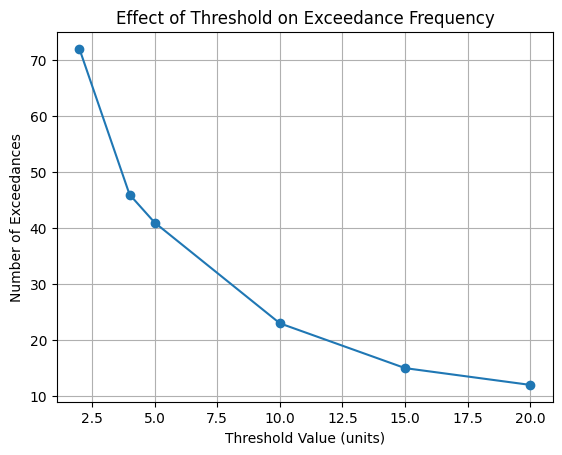

In [50]:
import matplotlib.pyplot as plt

thresholds = [2, 4, 5, 10, 15, 20]
exceedances = [72, 46, 41, 23, 15, 12]

plt.plot(thresholds, exceedances, marker='o')
plt.xlabel("Threshold Value (units)")
plt.ylabel("Number of Exceedances")
plt.title("Effect of Threshold on Exceedance Frequency")

plt.grid(True)
plt.show()